# Punto 1 – Diagnóstico

## 1.1 Top 5 productos / categorías por volumen y por ingresos

**Pregunta:** ¿Cuáles son los 5 productos (o categorías de productos) más vendidos en términos de volumen y cuáles en términos de ingresos totales?

**Decisiones analíticas** (registradas en `SUPUESTOS.md`):

| Decisión | Criterio | Por qué |
|---|---|---|
| Pedidos válidos | `order_status == 'delivered'` | Solo la venta entregada es ingreso realizado. Escenario de sensibilidad: todos los estados menos `canceled` y `unavailable` |
| Volumen | Filas de `order_items` (unidades) | 1 fila = 1 unidad vendida. Se reporta también pedidos distintos |
| Ingresos | Suma de `price` | Es el ingreso del producto. El flete no lo es; se reporta aparte como sensibilidad |
| Unidad de análisis | Categoría | El dataset no trae nombre de producto: el `product_id` es un hash. El top de SKU va como complemento |
| Sin categoría | Etiqueta `sin_categoria` | 610 productos sin etiqueta: se excluyen del ranking pero se reporta su peso |

### Preparación

In [1]:
import sys
from pathlib import Path

import pandas as pd

# El notebook corre desde notebooks/, pero las rutas del proyecto son desde la raíz
RUTA_PROYECTO = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RUTA_PROYECTO))

from src.data_loader import (
    ESTADOS_PRINCIPAL,
    ESTADOS_SENSIBILIDAD,
    RUTA_PROCESSED,
    cargar_datos,
    construir_items_enriquecidos,
)
from src.features import (
    comparar_tops,
    peso_sin_categoria,
    ranking_por_categoria,
    ranking_por_producto,
    top_categorias,
)
from src.utils import (
    formato_miles,
    formato_moneda,
    grafico_barras_horizontal,
    guardar_tabla,
    imprimir_checklist,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)

In [2]:
dfs = cargar_datos()
print({nombre: df.shape for nombre, df in dfs.items()})

{'clientes': (99441, 5), 'geolocalizacion': (1000163, 5), 'items_pedido': (112650, 7), 'pagos': (103886, 5), 'resenas': (99224, 7), 'pedidos': (99441, 8), 'productos': (32951, 9), 'vendedores': (3095, 4), 'traduccion_categorias': (71, 2)}


### Tabla base: ítems de pedidos entregados

Un merge con `pedidos` (donde `order_id` es único) y otro con el catálogo de productos (donde `product_id` es único). Ninguno de los dos puede aumentar el número de filas: si lo hiciera, habría duplicados.

In [3]:
items = construir_items_enriquecidos(dfs, estados_validos=ESTADOS_PRINCIPAL)
items.head()

Ítems totales                  : 112,650
Ítems de pedidos válidos       : 110,197 (['delivered'])
Ítems tras unir categoría      : 110,197
Merge con productos conserva filas: True
Categorías nulas tras el merge : 0


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,categoria_pt,categoria_en,categoria_es,ingreso_con_flete
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,cool_stuff,cool_stuff,Novedades,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,pet_shop,pet_shop,Mascotas,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,moveis_decoracao,furniture_decor,Muebles y decoración,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,perfumaria,perfumery,Perfumería,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,ferramentas_jardim,garden_tools,Herramientas de jardín,218.04


In [4]:
# Se guarda la tabla base para reutilizarla en los puntos 1.2, 2.x y 3.1
RUTA_PROCESSED.mkdir(parents=True, exist_ok=True)
items.to_parquet(RUTA_PROCESSED / "items_enriquecidos.parquet", index=False)
print("Guardado:", RUTA_PROCESSED / "items_enriquecidos.parquet", items.shape)

Guardado: C:\Users\user\Downloads\prueba-tecnica-proteccion-ds-ia\data\processed\items_enriquecidos.parquet (110197, 16)


### Ranking completo por categoría

Se calcula sobre las 73 categorías y se guarda entero, porque el punto 3.1 necesita los precios promedio.

In [5]:
ranking = ranking_por_categoria(items)
ranking.to_parquet(RUTA_PROCESSED / "ranking_categorias.parquet", index=False)
print("Categorías:", len(ranking))
ranking.head(10)

Categorías: 74


,categoria_es,unidades,pedidos,ingresos,ingresos_con_flete,precio_promedio,pct_unidades,pct_ingresos,pct_acum_ingresos
0,Belleza y salud,9465,8647,1233131.72,1412089.53,130.28,8.59,9.33,9.33
1,Relojes y regalos,5859,5495,1166176.98,1264333.12,199.04,5.32,8.82,18.15
2,"Cama, mesa y baño",10953,9272,1023434.76,1225209.26,93.44,9.94,7.74,25.89
3,Deporte y ocio,8431,7530,954852.55,1118256.91,113.25,7.65,7.22,33.11
4,Informática y accesorios,7644,6530,888724.61,1032723.77,116.26,6.94,6.72,39.83
5,Muebles y decoración,8160,6307,711927.69,880329.92,87.25,7.40,5.38,45.22
6,Utensilios domésticos,6795,5743,615628.69,758392.25,90.60,6.17,4.66,49.87
7,Novedades,3718,3559,610204.10,691680.89,164.12,3.37,4.62,54.49
8,Automotriz,4140,3810,578966.65,669454.75,139.85,3.76,4.38,58.87
9,Juguetes,4030,3804,471286.48,547061.06,116.94,3.66,3.56,62.43


### Top 5 por volumen (unidades vendidas)

In [6]:
top5_volumen = top_categorias(ranking, metrica="unidades", n=5)
guardar_tabla(top5_volumen, "1_1_top5_volumen.csv")
top5_volumen[["categoria_es", "unidades", "pedidos", "ingresos", "precio_promedio", "pct_unidades"]]

,categoria_es,unidades,pedidos,ingresos,precio_promedio,pct_unidades
0,"Cama, mesa y baño",10953,9272,1023434.76,93.44,9.94
1,Belleza y salud,9465,8647,1233131.72,130.28,8.59
2,Deporte y ocio,8431,7530,954852.55,113.25,7.65
3,Muebles y decoración,8160,6307,711927.69,87.25,7.40
4,Informática y accesorios,7644,6530,888724.61,116.26,6.94


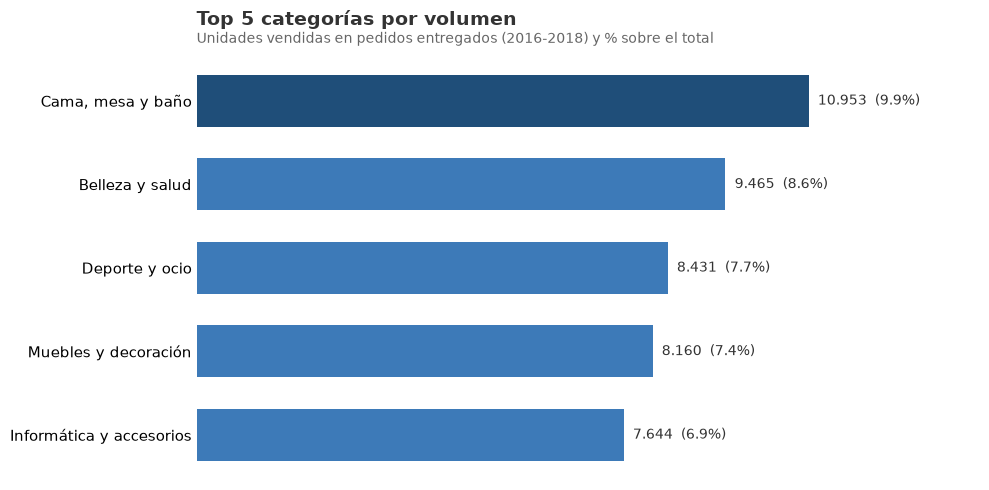

WindowsPath('C:/Users/user/Downloads/prueba-tecnica-proteccion-ds-ia/reports/figures/1_1_top5_volumen.png')

In [7]:
grafico_barras_horizontal(
    top5_volumen,
    columna_categoria="categoria_es",
    columna_valor="unidades",
    columna_porcentaje="pct_unidades",
    titulo="Top 5 categorías por volumen",
    subtitulo="Unidades vendidas en pedidos entregados (2016-2018) y % sobre el total",
    es_moneda=False,
    nombre_archivo="1_1_top5_volumen.png",
)

### Top 5 por ingresos (suma de `price`)

In [8]:
top5_ingresos = top_categorias(ranking, metrica="ingresos", n=5)
guardar_tabla(top5_ingresos, "1_1_top5_ingresos.csv")
top5_ingresos[["categoria_es", "ingresos", "unidades", "pedidos", "precio_promedio", "pct_ingresos"]]

,categoria_es,ingresos,unidades,pedidos,precio_promedio,pct_ingresos
0,Belleza y salud,1233131.72,9465,8647,130.28,9.33
1,Relojes y regalos,1166176.98,5859,5495,199.04,8.82
2,"Cama, mesa y baño",1023434.76,10953,9272,93.44,7.74
3,Deporte y ocio,954852.55,8431,7530,113.25,7.22
4,Informática y accesorios,888724.61,7644,6530,116.26,6.72


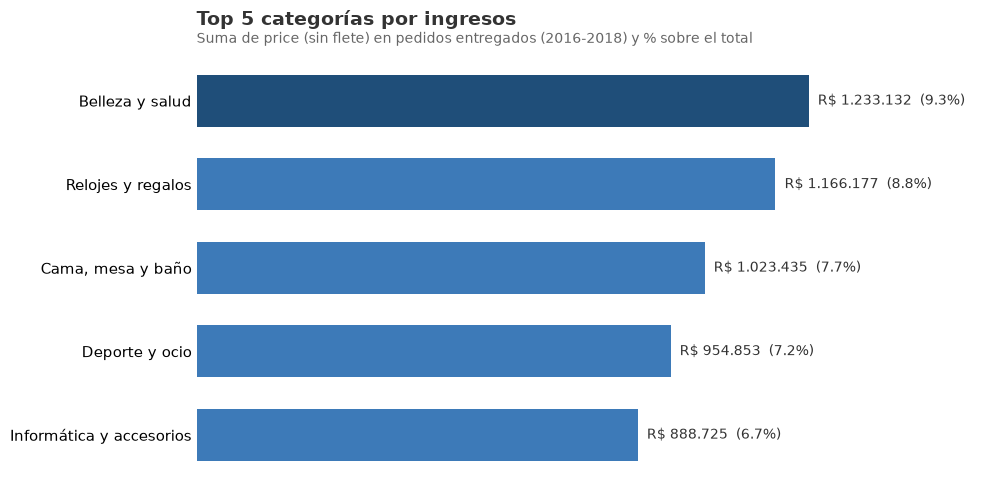

WindowsPath('C:/Users/user/Downloads/prueba-tecnica-proteccion-ds-ia/reports/figures/1_1_top5_ingresos.png')

In [9]:
grafico_barras_horizontal(
    top5_ingresos,
    columna_categoria="categoria_es",
    columna_valor="ingresos",
    columna_porcentaje="pct_ingresos",
    titulo="Top 5 categorías por ingresos",
    subtitulo="Suma de price (sin flete) en pedidos entregados (2016-2018) y % sobre el total",
    es_moneda=True,
    nombre_archivo="1_1_top5_ingresos.png",
)

### Volumen vs ingresos: qué categoría entra en un top y no en el otro

La explicación está en el ticket promedio: una categoría puede vender mucho a precio bajo o poco a precio alto.

In [10]:
comparacion = comparar_tops(top5_volumen, top5_ingresos)
for clave, categorias in comparacion.items():
    print(f"{clave:15}: {categorias}")

columnas = ["categoria_es", "unidades", "ingresos", "precio_promedio", "pct_unidades", "pct_ingresos"]
categorias_destacadas = set(top5_volumen["categoria_es"]) | set(top5_ingresos["categoria_es"])
ranking[ranking["categoria_es"].isin(categorias_destacadas)][columnas].sort_values("ingresos", ascending=False)

en_ambos       : ['Cama, mesa y baño', 'Belleza y salud', 'Deporte y ocio', 'Informática y accesorios']
solo_volumen   : ['Muebles y decoración']
solo_ingresos  : ['Relojes y regalos']


,categoria_es,unidades,ingresos,precio_promedio,pct_unidades,pct_ingresos
0,Belleza y salud,9465,1233131.72,130.28,8.59,9.33
1,Relojes y regalos,5859,1166176.98,199.04,5.32,8.82
2,"Cama, mesa y baño",10953,1023434.76,93.44,9.94,7.74
3,Deporte y ocio,8431,954852.55,113.25,7.65,7.22
4,Informática y accesorios,7644,888724.61,116.26,6.94,6.72
5,Muebles y decoración,8160,711927.69,87.25,7.40,5.38


### Sensibilidad

Dos supuestos se ponen a prueba: el filtro de estados y si el flete se cuenta como ingreso. Si el top 5 no cambia, la conclusión no depende del supuesto.

In [11]:
# Escenario laxo: todos los estados menos canceled y unavailable
items_laxo = construir_items_enriquecidos(dfs, estados_validos=ESTADOS_SENSIBILIDAD, verbose=False)
ranking_laxo = ranking_por_categoria(items_laxo)

comparaciones = {
    "Volumen – principal (delivered)": top_categorias(ranking, "unidades", 5)["categoria_es"].tolist(),
    "Volumen – laxo (sin canceled/unavailable)": top_categorias(ranking_laxo, "unidades", 5)["categoria_es"].tolist(),
    "Ingresos – principal (price)": top_categorias(ranking, "ingresos", 5)["categoria_es"].tolist(),
    "Ingresos – laxo (price)": top_categorias(ranking_laxo, "ingresos", 5)["categoria_es"].tolist(),
    "Ingresos – principal con flete": top_categorias(ranking, "ingresos_con_flete", 5)["categoria_es"].tolist(),
}
for escenario, top in comparaciones.items():
    print(f"{escenario:45}: {top}")

print()
print("¿El top 5 de volumen cambia con el filtro?  ",
      comparaciones["Volumen – principal (delivered)"] != comparaciones["Volumen – laxo (sin canceled/unavailable)"])
print("¿El top 5 de ingresos cambia con el filtro? ",
      comparaciones["Ingresos – principal (price)"] != comparaciones["Ingresos – laxo (price)"])
print("¿El top 5 de ingresos cambia con el flete?  ",
      comparaciones["Ingresos – principal (price)"] != comparaciones["Ingresos – principal con flete"])

Volumen – principal (delivered)              : ['Cama, mesa y baño', 'Belleza y salud', 'Deporte y ocio', 'Muebles y decoración', 'Informática y accesorios']
Volumen – laxo (sin canceled/unavailable)    : ['Cama, mesa y baño', 'Belleza y salud', 'Deporte y ocio', 'Muebles y decoración', 'Informática y accesorios']
Ingresos – principal (price)                 : ['Belleza y salud', 'Relojes y regalos', 'Cama, mesa y baño', 'Deporte y ocio', 'Informática y accesorios']
Ingresos – laxo (price)                      : ['Belleza y salud', 'Relojes y regalos', 'Cama, mesa y baño', 'Deporte y ocio', 'Informática y accesorios']
Ingresos – principal con flete               : ['Belleza y salud', 'Relojes y regalos', 'Cama, mesa y baño', 'Deporte y ocio', 'Informática y accesorios']

¿El top 5 de volumen cambia con el filtro?   False
¿El top 5 de ingresos cambia con el filtro?  False
¿El top 5 de ingresos cambia con el flete?   False


### Complemento: top 5 productos (SKU)

In [12]:
top5_productos_volumen = ranking_por_producto(items, metrica="unidades", n=5)
top5_productos_volumen

,product_id,categoria_es,categoria_en,unidades,pedidos,ingresos,precio_promedio
0,aca2eb7d00ea1a7b8ebd4e68314663af,Muebles y decoración,furniture_decor,520,425,37104.30,71.35
1,422879e10f46682990de24d770e7f83d,Herramientas de jardín,garden_tools,484,352,26577.22,54.91
2,99a4788cb24856965c36a24e339b6058,"Cama, mesa y baño",bed_bath_table,477,456,42049.66,88.15
3,389d119b48cf3043d311335e499d9c6b,Herramientas de jardín,garden_tools,390,309,21336.79,54.71
4,368c6c730842d78016ad823897a372db,Herramientas de jardín,garden_tools,388,291,21056.80,54.27


In [13]:
top5_productos_ingresos = ranking_por_producto(items, metrica="ingresos", n=5)
top5_productos_ingresos

,product_id,categoria_es,categoria_en,unidades,pedidos,ingresos,precio_promedio
0,bb50f2e236e5eea0100680137654686c,Belleza y salud,health_beauty,194,186,63560.00,327.63
1,6cdd53843498f92890544667809f1595,Belleza y salud,health_beauty,153,148,53652.30,350.67
2,d6160fb7873f184099d9bc95e30376af,Computadores,computers,33,33,45949.35,1392.40
3,d1c427060a0f73f6b889a5c7c61f2ac4,Informática y accesorios,computers_accessories,332,313,45620.56,137.41
4,99a4788cb24856965c36a24e339b6058,"Cama, mesa y baño",bed_bath_table,477,456,42049.66,88.15


### Peso de los productos sin categoría

In [14]:
sin_cat = peso_sin_categoria(ranking)
print(f"Unidades sin categoría: {formato_miles(sin_cat['unidades'])} ({sin_cat['pct_unidades']:.2f}% del volumen)")
print(f"Ingresos sin categoría: {formato_moneda(sin_cat['ingresos'])} ({sin_cat['pct_ingresos']:.2f}% de los ingresos)")

Unidades sin categoría: 1.537 (1.39% del volumen)
Ingresos sin categoría: R$ 170.727 (1.29% de los ingresos)


### Validación

In [15]:
items_sin_filtro = dfs["items_pedido"]
pedidos_entregados = dfs["pedidos"]["order_status"].eq("delivered").sum()
diferencia_ingresos = abs(ranking["ingresos"].sum() - items["price"].sum())

validaciones = [
    ("Ítems antes/después del merge con productos",
     len(items) == len(items[items["categoria_pt"].notna()]),
     f"{len(items):,} filas, 0 categorías nulas"),
    ("Pedidos entregados sin duplicar ítems",
     items["order_id"].nunique() == pedidos_entregados,
     f"{items['order_id'].nunique():,} pedidos = {pedidos_entregados:,} entregados"),
    ("Suma de unidades por categoría = filas de ítems filtrados",
     int(ranking["unidades"].sum()) == len(items),
     f"{int(ranking['unidades'].sum()):,} = {len(items):,}"),
    ("Suma de ingresos por categoría = price filtrado",
     diferencia_ingresos < 0.01,
     f"diferencia = R$ {diferencia_ingresos:.4f}"),
    ("Total de price sin filtro ≈ R$ 13,6M",
     13.5e6 < items_sin_filtro["price"].sum() < 13.7e6,
     formato_moneda(items_sin_filtro["price"].sum())),
    ("Peso de sin_categoria reportado",
     sin_cat["pct_unidades"] < 5,
     f"{sin_cat['pct_unidades']:.2f}% unidades / {sin_cat['pct_ingresos']:.2f}% ingresos"),
]
imprimir_checklist(validaciones)

CHECKLIST DE VALIDACIÓN
----------------------------------------------------------------------
✅ Ítems antes/después del merge con productos: 110,197 filas, 0 categorías nulas
✅ Pedidos entregados sin duplicar ítems: 96,478 pedidos = 96,478 entregados
✅ Suma de unidades por categoría = filas de ítems filtrados: 110,197 = 110,197
✅ Suma de ingresos por categoría = price filtrado: diferencia = R$ 0.0000
✅ Total de price sin filtro ≈ R$ 13,6M: R$ 13.591.644
✅ Peso de sin_categoria reportado: 1.39% unidades / 1.29% ingresos
----------------------------------------------------------------------
TODAS LAS VALIDACIONES PASARON


True

### Conclusiones 1.1

1. **Volumen:** Cama, mesa y baño (10.953 unidades · 9,9%), Belleza y salud (9.465 · 8,6%), Deporte y ocio (8.431 · 7,7%), Muebles y decoración (8.160 · 7,4%) e Informática y accesorios (7.644 · 6,9%).
2. **Ingresos:** Belleza y salud (R$ 1.233.132 · 9,3%), Relojes y regalos (R$ 1.166.177 · 8,8%), Cama, mesa y baño (R$ 1.023.435 · 7,7%), Deporte y ocio (R$ 954.853 · 7,2%) e Informática y accesorios (R$ 888.725 · 6,7%).
3. **El hallazgo:** cuatro categorías aparecen en ambos tops. La diferencia la explica el ticket promedio: Relojes y regalos entra solo por ingresos (5.859 unidades, pero R$ 199 por unidad) y Muebles y decoración solo por volumen (R$ 87 por unidad). Belleza y salud es la única que lidera las dos métricas, así que es la categoría ancla del negocio.
4. **Robustez:** el top 5 es idéntico con el filtro laxo (todo menos `canceled` y `unavailable`) y al sumar el flete. La respuesta no depende del supuesto de filtrado.
5. **Concentración:** el mercado está muy fragmentado. Las 5 categorías líderes suman apenas el 40% de los ingresos, repartidos entre 73 categorías.
6. **Nivel SKU:** los productos más vendidos en unidades son de Muebles y decoración y Herramientas de jardín (ticket de R$ 55 a R$ 88), mientras los de mayor ingreso son de Belleza y salud (R$ 328 a R$ 351) y un computador de R$ 1.392. Estos SKU alimentan la base de conocimiento del punto 3.1.
7. **Calidad:** los productos sin categoría pesan 1,39% de las unidades y 1,29% de los ingresos, así que excluirlos del ranking no altera las conclusiones.

---

## 1.2 Mayor dolor del cliente y categorías asociadas

**Pregunta:** ¿Cuál es el mayor dolor de nuestros clientes y qué productos o categorías están directamente relacionados con estas malas experiencias?

**Decisiones analíticas** (registradas en `SUPUESTOS.md`):

| Decisión | Criterio | Por qué |
|---|---|---|
| Mala experiencia | `review_score <= 2` | Es el dolor declarado por el propio cliente. 3 es neutral, 4-5 buena |
| Reseñas duplicadas | 1 por pedido, la más reciente | 551 `order_id` repetidos inflarían las tasas |
| Pedidos incluidos | Todos los estados | Un pedido cancelado o no entregado también es dolor; se analiza como grupo aparte |
| Retraso | `entrega_real - entrega_estimada` en días | Al cliente le duele el incumplimiento de la promesa, no la duración en sí |
| Umbral por categoría | ≥ 300 pedidos con reseña | Evita que una categoría con 12 ventas y 4 quejas encabece el ranking |

### Tabla a nivel pedido: reseña, retraso y composición

In [16]:
from src.features import (
    dolor_por_categoria,
    construir_pedidos_experiencia,
    deduplicar_resenas,
    entregas_tarde_por_estado,
    experiencia_por_rango_retraso,
    perfil_dolor_cliente,
    tabla_dolores,
)
from src.nlp_resenas import (
    TEMAS,
    clasificar_temas,
    ejemplos_por_tema,
    resumen_temas,
    top_ngramas,
)
from src.utils import grafico_barras_vertical

resenas_unicas = deduplicar_resenas(dfs["resenas"])
print(f"Reseñas originales : {len(dfs['resenas']):,}")
print(f"Reseñas únicas     : {len(resenas_unicas):,} (1 por pedido: {resenas_unicas['order_id'].is_unique})")

exp = construir_pedidos_experiencia(dfs)
print(f"Pedidos            : {len(exp):,}")
print(f"Sin reseña         : {(~exp['tiene_resena']).sum():,}")
print(f"Sin fecha de entrega (no se puede calcular retraso): {exp['retraso_dias'].isna().sum():,}")
exp[["order_id", "order_status", "review_score", "mala_experiencia", "retraso_dias", "rango_retraso", "n_items"]].head()

Reseñas originales : 99,224
Reseñas únicas     : 98,673 (1 por pedido: True)


Pedidos            : 99,441
Sin reseña         : 768
Sin fecha de entrega (no se puede calcular retraso): 2,965


,order_id,order_status,review_score,mala_experiencia,retraso_dias,rango_retraso,n_items
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,4.0,False,-8.0,a tiempo,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,4.0,False,-6.0,a tiempo,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,5.0,False,-18.0,a tiempo,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,5.0,False,-13.0,a tiempo,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,5.0,False,-10.0,a tiempo,1.0


In [17]:
exp.to_parquet(RUTA_PROCESSED / "pedidos_experiencia.parquet", index=False)
print("Guardado:", RUTA_PROCESSED / "pedidos_experiencia.parquet", exp.shape)

Guardado: C:\Users\user\Downloads\prueba-tecnica-proteccion-ds-ia\data\processed\pedidos_experiencia.parquet (99441, 29)


### ¿Cuál es el dolor? Comparación de candidatos

Cada grupo expuesto a un problema se compara contra su control. Lo que importa es la combinación de **tasa** (qué tan grave) e **impacto** (a cuántos afecta).

In [18]:
dolores = tabla_dolores(exp)
guardar_tabla(dolores, "1_2_dolores.csv")
dolores

,dolor,pedidos,pedidos_con_resena,tasa_mala_experiencia,score_promedio,malas_experiencias
0,Entrega tarde (retraso > 0 días),6534,6381,62.42,2.27,3983
1,Entrega a tiempo (control),89936,89443,9.27,4.29,8289
2,Pedido cancelado o no disponible,1234,1200,80.83,1.66,970
3,Entrega lenta a tiempo (> 18 días),10228,10151,13.97,3.99,1418
4,Flete > 50% del valor del producto,15499,15499,14.92,4.06,2312
5,Flete <= 50% (control),82418,82418,14.05,4.11,11581
6,Pedido con varios vendedores,1264,1264,47.31,2.86,598
7,Pedido con varios ítems,9690,9690,27.67,3.60,2681
8,Pedido de un solo ítem (control),88227,88227,12.71,4.16,11212


In [19]:
retraso = experiencia_por_rango_retraso(exp)
retraso

,rango_retraso,pedidos,score_promedio,tasa_mala_experiencia
0,a tiempo,89443,4.29,9.27
1,1-3 días,1852,3.29,32.13
2,4-7 días,1748,2.10,67.68
3,8-14 días,1446,1.67,80.15
4,más de 14 días,1335,1.72,78.35


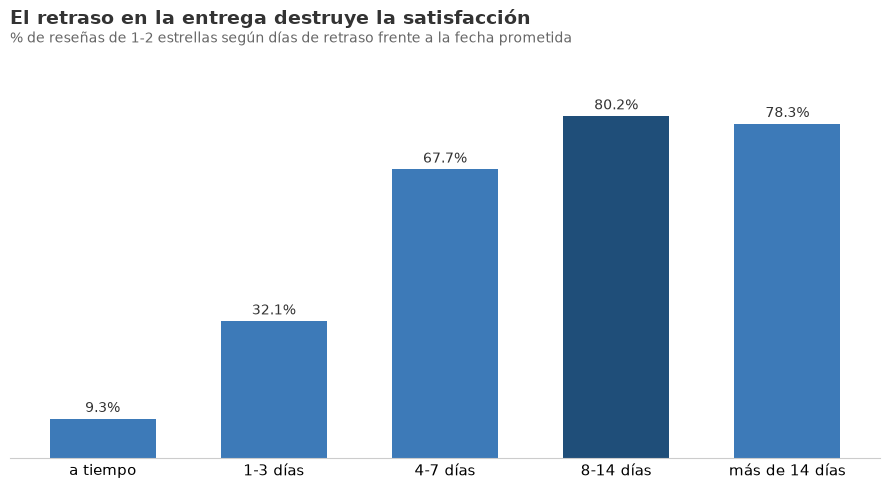

WindowsPath('C:/Users/user/Downloads/prueba-tecnica-proteccion-ds-ia/reports/figures/1_2_retraso_vs_satisfaccion.png')

In [20]:
grafico_barras_vertical(
    retraso,
    columna_categoria="rango_retraso",
    columna_valor="tasa_mala_experiencia",
    titulo="El retraso en la entrega destruye la satisfacción",
    subtitulo="% de reseñas de 1-2 estrellas según días de retraso frente a la fecha prometida",
    nombre_archivo="1_2_retraso_vs_satisfaccion.png",
)

### ¿De qué se quejan? Análisis de los comentarios negativos

Los comentarios están en portugués. Se limpian (minúsculas, sin tildes, sin stopwords) y se clasifican por temas con diccionarios de palabras clave. Un comentario puede tocar varios temas, así que los porcentajes no suman 100.

In [21]:
negativas = exp[exp["mala_experiencia"] & exp["review_comment_message"].notna()]
positivas = exp[(exp["review_score"] >= 4) & exp["review_comment_message"].notna()]
print(f"Comentarios negativos: {len(negativas):,} | positivos: {len(positivas):,}")

comparacion_palabras = pd.concat([
    top_ngramas(negativas["review_comment_message"], n=1, top=12).rename(
        columns={"expresion": "negativas", "frecuencia": "frec_neg"}),
    top_ngramas(positivas["review_comment_message"], n=1, top=12).rename(
        columns={"expresion": "positivas", "frecuencia": "frec_pos"}),
], axis=1)
comparacion_palabras

Comentarios negativos: 10,839 | positivos: 26,398


,negativas,frec_neg,positivas,frec_pos
0,produto,6167,produto,10606
1,recebi,3257,prazo,7033
2,comprei,1862,antes,5254
3,veio,1550,entrega,4609
4,entrega,1407,chegou,3998
5,entregue,1325,bom,3989
6,chegou,1173,recomendo,3858
7,prazo,915,bem,2688
8,compra,907,otimo,2370
9,pedido,793,entregue,2157


In [22]:
top_ngramas(negativas["review_comment_message"], n=2, top=12)

,expresion,frecuencia
0,recebi produto,1226
1,produto entregue,516
2,produto chegou,377
3,produto veio,373
4,nota fiscal,254
5,prazo entrega,240
6,comprei produto,223
7,recebi apenas,205
8,comprei dois,165
9,dinheiro volta,152


In [23]:
marcas = clasificar_temas(negativas)
temas = resumen_temas(marcas)
temas

,tema,comentarios,pct_comentarios
0,entrega / retraso,6117,56.44
1,atención / vendedor,1945,17.94
2,producto errado / incompleto,1852,17.09
3,sin tema identificado,1729,15.95
4,reembolso / cancelación,1589,14.66
5,producto defectuoso / calidad,1460,13.47
6,no cumple expectativas,834,7.69


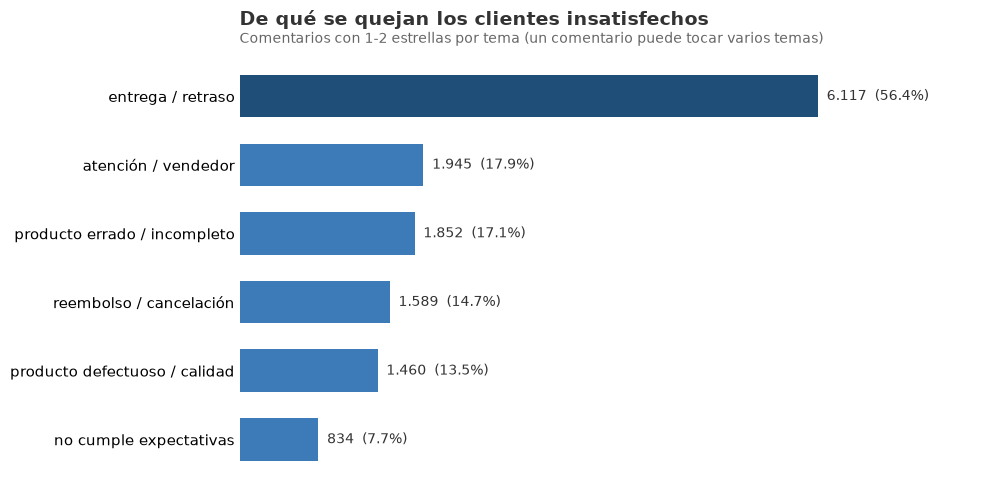

WindowsPath('C:/Users/user/Downloads/prueba-tecnica-proteccion-ds-ia/reports/figures/1_2_temas_quejas.png')

In [24]:
grafico_barras_horizontal(
    temas[temas["tema"] != "sin tema identificado"],
    columna_categoria="tema",
    columna_valor="comentarios",
    columna_porcentaje="pct_comentarios",
    titulo="De qué se quejan los clientes insatisfechos",
    subtitulo="Comentarios con 1-2 estrellas por tema (un comentario puede tocar varios temas)",
    es_moneda=False,
    nombre_archivo="1_2_temas_quejas.png",
)

In [25]:
for tema in TEMAS:
    print(f"\n--- {tema.upper()} ---")
    for ejemplo in ejemplos_por_tema(marcas, tema, n=3):
        print(" •", ejemplo)


--- ENTREGA / RETRASO ---
 • Demora muito entregar. Já passou o prazo e ainda não recebi minha encomenda.
 • Não recebi
 • Boa noite, não recebi o escorredor de louça, Continuo no aguardo

--- PRODUCTO DEFECTUOSO / CALIDAD ---
 • A cuba veio quebrada. Como efetuo barroca?
 • Recebi um produto velho
 • meu produto veio com o cabo todo arranhado, produto parece usado

--- PRODUCTO ERRADO / INCOMPLETO ---
 • mais ou menos o produto veio faltando uma peca
 • Produto não corresponde às expectativas
 • Faltou a FLANGE da cadeira que e considerada a peça mais importante.

--- ATENCIÓN / VENDEDOR ---
 • Mais respeito ao consumidor, era para presente!!
 • Vendedor até agora não mando meu pedido
 • Já abri um chamado e não tenho resposta de quando terei o produto comprado.

--- REEMBOLSO / CANCELACIÓN ---
 • QUERO fazer a devolução. 
Qual procedimento, por favor?
 • Eu quero meu dinheiro de volta
 • Quero cancelar essa compra

--- NO CUMPLE EXPECTATIVAS ---
 • N gostei do produto n era oq imagi

### Categorías asociadas a las malas experiencias

Se deduplica el par pedido-categoría. Un pedido con ítems de 2 categorías cuenta en ambas, por eso la suma por categoría supera el total de pedidos con mala experiencia.

In [26]:
categorias_dolor = dolor_por_categoria(items, exp)
guardar_tabla(categorias_dolor, "1_2_categorias_dolor.csv")

print("TOP 10 POR IMPACTO (número de malas experiencias)")
categorias_dolor.head(10)

TOP 10 POR IMPACTO (número de malas experiencias)


,categoria_es,pedidos,score_promedio,tasa_mala_experiencia,malas_experiencias,pct_tarde,retraso_promedio_dias
0,"Cama, mesa y baño",9177,4.00,16.03,1471,7.28,-11.44
1,Belleza y salud,8601,4.23,11.45,985,7.36,-12.02
2,Muebles y decoración,6260,4.06,15.35,961,7.03,-12.38
3,Informática y accesorios,6499,4.08,14.56,946,6.26,-12.41
4,Deporte y ocio,7486,4.23,11.38,852,6.51,-11.88
5,Relojes y regalos,5454,4.12,13.70,747,7.24,-11.85
6,Utensilios domésticos,5709,4.19,11.82,675,5.25,-12.13
7,Telefonía,4069,4.05,14.13,575,7.05,-11.26
8,Automotriz,3792,4.15,13.00,493,7.20,-11.28
9,Juguetes,3774,4.24,11.39,430,6.15,-12.17


In [27]:
print("TOP 10 POR TASA (% de malas experiencias, mínimo 300 pedidos)")
categorias_dolor.sort_values("tasa_mala_experiencia", ascending=False).head(10)

TOP 10 POR TASA (% de malas experiencias, mínimo 300 pedidos)


,categoria_es,pedidos,score_promedio,tasa_mala_experiencia,malas_experiencias,pct_tarde,retraso_promedio_dias
15,Muebles de oficina,1244,3.64,21.95,273,7.96,-11.87
25,Audio,345,3.84,21.74,75,11.59,-10.06
26,Confort para el hogar,390,3.88,18.72,73,9.49,-9.76
16,Sin categoría,1382,4.01,17.44,241,7.24,-11.40
23,Casa y construcción,481,3.99,17.26,83,6.03,-11.40
0,"Cama, mesa y baño",9177,4.00,16.03,1471,7.28,-11.44
2,Muebles y decoración,6260,4.06,15.35,961,7.03,-12.38
3,Informática y accesorios,6499,4.08,14.56,946,6.26,-12.41
11,Bebés,2787,4.10,14.28,398,7.89,-11.59
29,Muebles de sala,409,4.07,14.18,58,7.09,-11.85


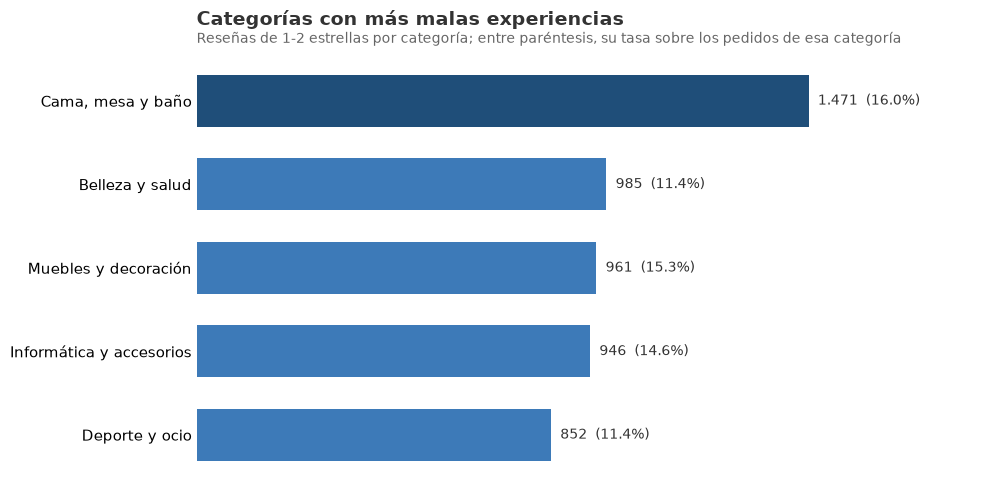

WindowsPath('C:/Users/user/Downloads/prueba-tecnica-proteccion-ds-ia/reports/figures/1_2_categorias_impacto.png')

In [28]:
grafico_barras_horizontal(
    categorias_dolor.head(5).assign(pct=lambda d: d["tasa_mala_experiencia"]),
    columna_categoria="categoria_es",
    columna_valor="malas_experiencias",
    columna_porcentaje="pct",
    titulo="Categorías con más malas experiencias",
    subtitulo="Reseñas de 1-2 estrellas por categoría; entre paréntesis, su tasa sobre los pedidos de esa categoría",
    es_moneda=False,
    nombre_archivo="1_2_categorias_impacto.png",
)

### Complemento: dónde falla la logística (estados con más entregas tarde)

In [29]:
estados = entregas_tarde_por_estado(exp)
estados.head(10)

,customer_state,pedidos,pct_tarde,retraso_promedio_dias,score_promedio
0,AL,397,21.41,-8.71,3.85
1,MA,717,17.43,-9.57,3.83
2,SE,335,15.22,-10.02,3.91
3,PI,476,13.87,-11.31,3.99
4,CE,1279,13.76,-10.80,3.94
5,BA,3256,12.16,-10.79,3.93
6,RJ,12350,12.11,-11.76,3.97
7,PA,946,11.21,-14.07,3.91
8,ES,1995,10.73,-10.50,4.08
9,PB,517,10.44,-13.26,4.08


### Perfil de dolor por cliente

Insumo directo de los puntos 2.1 (clientes en riesgo) y 3.2 (escenario del cliente con mala experiencia previa).

In [30]:
clientes_dolor = perfil_dolor_cliente(exp, temas=marcas)
clientes_dolor.to_parquet(RUTA_PROCESSED / "clientes_dolor.parquet", index=False)

print(f"Clientes: {len(clientes_dolor):,}")
print(f"Con al menos una mala experiencia: {clientes_dolor['tuvo_mala_experiencia'].sum():,} "
      f"({clientes_dolor['tuvo_mala_experiencia'].mean() * 100:.1f}%)")
print()
print(clientes_dolor[clientes_dolor["tuvo_mala_experiencia"]]["motivo_principal"].value_counts())

Clientes: 96,096
Con al menos una mala experiencia: 14,254 (14.8%)

motivo_principal
entrega / retraso                6012
sin motivo declarado             2122
sin tema identificado            1711
entrega tarde                    1222
producto defectuoso / calidad    1046
producto errado / incompleto      972
atención / vendedor               399
reembolso / cancelación           333
pedido no entregado               247
no cumple expectativas            190
Name: count, dtype: int64


### Validación

In [31]:
pedidos_con_resena = int(exp["tiene_resena"].sum())
malas_totales = int(exp["mala_experiencia"].sum())
suma_categorias = int(categorias_dolor["malas_experiencias"].sum())
clasificados = (marcas["n_temas"] > 0).mean() * 100

validaciones_12 = [
    ("Reseñas deduplicadas: 1 por pedido",
     resenas_unicas["order_id"].is_unique and len(resenas_unicas) == 98673,
     f"{len(dfs['resenas']):,} -> {len(resenas_unicas):,} filas"),
    ("Merge no alteró el número de pedidos",
     len(exp) == len(dfs["pedidos"]),
     f"{len(exp):,} = {len(dfs['pedidos']):,}"),
    ("Pedidos sin fecha de entrega excluidos solo del retraso",
     exp["retraso_dias"].isna().sum() == exp["order_delivered_customer_date"].isna().sum(),
     f"{exp['retraso_dias'].isna().sum():,} pedidos sin retraso calculable"),
    ("Malas experiencias por categoría ≥ total (pedido multi-categoría cuenta en cada una)",
     suma_categorias <= malas_totales * 1.3,
     f"{suma_categorias:,} vs {malas_totales:,} malas experiencias totales"),
    ("Comentarios negativos clasificados en al menos un tema",
     clasificados >= 80,
     f"{clasificados:.1f}% de {len(marcas):,} comentarios"),
    ("Cobertura de reseñas sobre pedidos",
     pedidos_con_resena / len(exp) > 0.98,
     f"{pedidos_con_resena:,} de {len(exp):,} pedidos ({pedidos_con_resena / len(exp) * 100:.1f}%)"),
]
imprimir_checklist(validaciones_12)

CHECKLIST DE VALIDACIÓN
----------------------------------------------------------------------
✅ Reseñas deduplicadas: 1 por pedido: 99,224 -> 98,673 filas
✅ Merge no alteró el número de pedidos: 99,441 = 99,441
✅ Pedidos sin fecha de entrega excluidos solo del retraso: 2,965 pedidos sin retraso calculable
✅ Malas experiencias por categoría ≥ total (pedido multi-categoría cuenta en cada una): 12,025 vs 14,494 malas experiencias totales
✅ Comentarios negativos clasificados en al menos un tema: 84.0% de 10,839 comentarios
✅ Cobertura de reseñas sobre pedidos: 98,673 de 99,441 pedidos (99.2%)
----------------------------------------------------------------------
TODAS LAS VALIDACIONES PASARON


True

### Conclusiones 1.2

1. **El mayor dolor es el incumplimiento de la entrega.** Un pedido que llega tarde tiene **62,4%** de reseñas de 1-2 estrellas contra **9,3%** de los que llegan a tiempo: multiplica el malestar por **6,7**. Son 6.534 pedidos tarde que generan **3.983 malas experiencias, el 27% de todas las del negocio**, con apenas el 6,8% de los pedidos entregados.
2. **Lo confirma la voz del cliente:** el **56,4%** de los 10.839 comentarios negativos habla de entrega o retraso, muy por encima de atención (17,9%), producto errado o incompleto (17,1%), reembolso (14,7%) y producto defectuoso (13,5%).
3. **El daño no es lineal, hay un umbral:** 1-3 días de retraso ya llevan la insatisfacción a 32,1%, de 4 a 7 días salta a 67,7% y de 8 a 14 días a 80,2%. **Los primeros 3 días son la zona donde todavía se puede salvar al cliente** con aviso proactivo y compensación.
4. **El caso extremo es el pedido que nunca llega:** cancelado o no disponible tiene 80,8% de malas reseñas y score promedio de 1,66. Son solo 1.234 pedidos, pero es el dolor más intenso.
5. **Categorías por impacto** (dónde se concentra el volumen de quejas): Cama, mesa y baño (1.471 malas experiencias · 16,0% de sus pedidos), Belleza y salud (985 · 11,5%), Muebles y decoración (961 · 15,4%), Informática y accesorios (946 · 14,6%) y Deporte y ocio (852 · 11,4%). Son las mismas categorías del top de ventas del 1.1: **donde más se vende es donde más duele**.
6. **Categorías por tasa** (dónde el servicio está peor): Muebles de oficina (22,0%), Audio (21,7%), Confort para el hogar (18,7%), Sin categoría (17,4%) y Casa y construcción (17,3%). Audio destaca por logística (11,6% de entregas tarde), mientras Muebles de oficina falla más por producto (score 3,64 con solo 8,0% de entregas tarde).
7. **Dónde falla la logística:** Alagoas (21,4% de entregas tarde), Maranhão (17,4%) y Sergipe (15,2%) son los peores en tasa, pero **Río de Janeiro es la prioridad real**: 12,1% de retrasos sobre 12.350 pedidos, es decir el mayor volumen absoluto de clientes afectados.
8. **Lo que NO es dolor:** el flete caro apenas mueve la aguja (14,9% de malas reseñas con flete > 50% del producto vs 14,1% del resto). En cambio los pedidos con varios vendedores sí (47,3%), porque multiplican las probabilidades de que algo llegue tarde.
9. **Para los puntos 2.1 y 3.2:** 14.254 clientes (14,8%) tienen al menos una mala experiencia registrada, con su motivo principal en `clientes_dolor.parquet`. Son el público objetivo del escenario de recuperación del agente de IA.

**Nota metodológica:** el 16% de los comentarios negativos no cae en ningún tema. Al revisarlos, buena parte son textos positivos con calificación baja o mensajes vacíos, así que no se fuerza su clasificación.